# Исследование фазовых портретов

Перед прочтением ~~сжечь~~ стереть выходы.

In [ ]:
# tech, skip it
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp

In [ ]:
# tech, skip it
def toTuple(UV):
    print(UV.shape)
    return UV[...,0], UV[...,1]
def fromTuple(UVtuple):
    print(UVtuple[0].shape)
    return np.concatenate([UVtuple[0][...,None],UVtuple[1][...,None]],axis=-1)

def makeStreamPlot(xx,vv,f,title="",xlabel="X",ylabel="Y",density=0.6):
    XVMesh = np.meshgrid(xx,vv)
    U, V = toTuple(f(0,fromTuple(XVMesh)))
  
    fig, ax = plt.subplots()

    ax.grid()
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)

    ax.streamplot(xx,vv, U, V, density=density, color='k', linewidth=0.7)

    return fig,ax

В этом ноутбуке мы посмотрим, как можно руками начать исследовать потоки, порождаемые дифференциальными уравнениями.

## Математический маятник

$$
\ddot{x} = - \omega^2 x, ~~ x(0)=x_0, ~\dot{x}(0)=v_0.
$$

In [42]:
omSq = 0.5
def fPendMath(t,x):
    '''
    Assumed x (...,2,) and t ()
    '''
    return np.concatenate([x[...,1:2],-omSq*x[...,0:1]], axis=-1) # 0:1 trick to conserve the dimensionality

(10, 10)
(10, 10, 2)


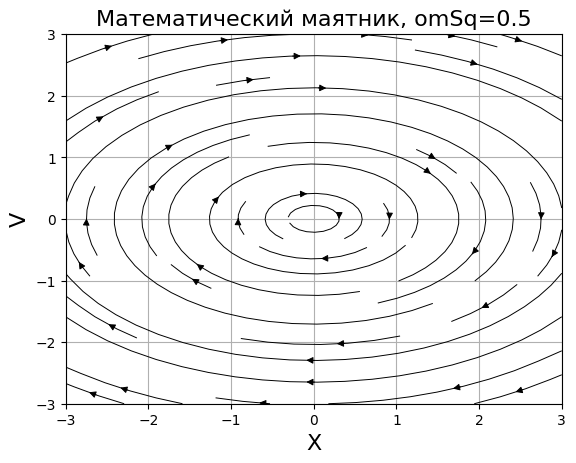

In [43]:
xs = np.linspace(-3, 3, 10)
vs = np.linspace(-3, 3, 10)
f,ax = makeStreamPlot(xs,vs, fPendMath, 
                      title=f"Математический маятник, omSq={omSq}",
                      xlabel="X",
                      ylabel="V")

## Физический маятник

$$
\ddot{x} = - \omega^2 \sin(x), ~~ x(0)=x_0, ~\dot{x}(0)=v_0.
$$

In [114]:
omSq=0.25
def fPendPhys(t,x):
    '''
    Assumed x (...,2) and t ()
    '''
    return np.concatenate([x[...,1:2],-omSq*np.sin(x[...,0:1])], axis=-1) # 0:1 trick to conserve the dimensionality

(60, 60)
(60, 60, 2)


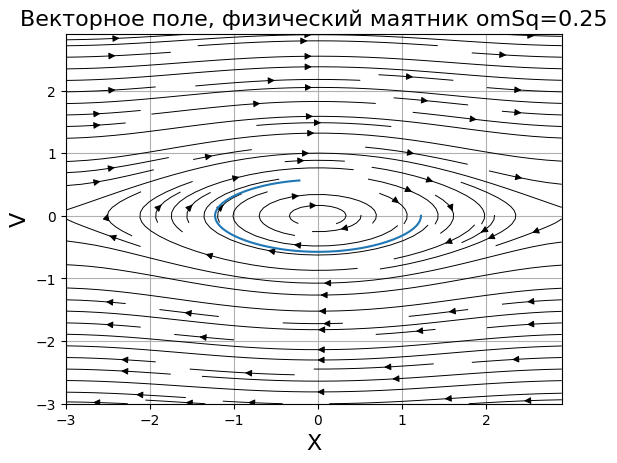

In [ ]:
xx = np.arange(-3, 3, 0.1)
vv = np.arange(-3, 3, 0.1)
#makeStreamPlot(xx,vv,fPendMath, title=f"Векторное поле, математический маятник omSq={omSq}")
_,ax=makeStreamPlot(xx,vv,fPendPhys, title=f"Векторное поле, физический маятник omSq={omSq}",
               xlabel="X",ylabel="V", density=1.1)


Здесь приходится решать численно.

In [121]:
X0 = np.array([np.sqrt(3/2),0])
ts = np.linspace(0,10,100)
sol = scp.integrate.solve_ivp(fun=fPendPhys, y0=X0, t_span=np.array([0,20]), t_eval=ts)
X0_1 = np.array([1/np.sqrt(2),1])
sol1 = scp.integrate.solve_ivp(fun=fPendPhys, y0=X0_1, t_span=np.array([0,20]), t_eval=ts)

In [125]:
def drawTraj(ax,y):
    ax.plot(y[0,:],y[1,:])
    ax.scatter(y[0,0],y[1,0],marker="o", color="green",s=50)
    ax.scatter(y[0,-1],y[1,-1],marker="x", color="red",s=50)

(60, 130)
(60, 130, 2)


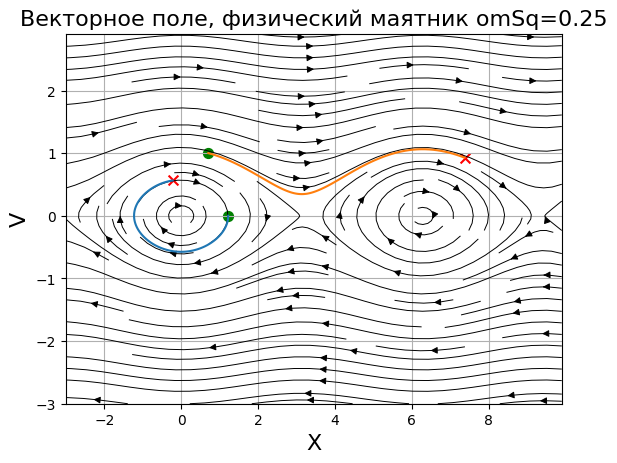

In [126]:
xx = np.arange(-3, 10, 0.1)
vv = np.arange(-3, 3, 0.1)
#makeStreamPlot(xx,vv,fPendMath, title=f"Векторное поле, математический маятник omSq={omSq}")
_,ax=makeStreamPlot(xx,vv,fPendPhys, title=f"Векторное поле, физический маятник omSq={omSq}",
               xlabel="X",ylabel="V", density=1.1)

drawTraj(ax,sol.y)
drawTraj(ax,sol1.y)

## Физический маятник с трением

$$
\dot{x} = v, ~ \dot{v}= - \omega^2 \sin(x) - r v^2\text{sign}(v), ~~ x(0)=x_0, ~v(0)=v_0.
$$

In [62]:
omSq=0.25
rDrag=0.2
def fPendPhysDrag(t,x):
    '''
    Assumed x (...,2) and t ()
    '''
    return np.concatenate([x[...,1:2],-omSq*np.sin(x[...,0:1]) -np.sign(x[...,1:2])*rDrag*x[...,1:2]**2], axis=-1) # 0:1 trick to conserve the dimensionality

Тоже решим численно.

In [140]:
X0 = np.array([np.sqrt(3/2),1.5])
ts = np.linspace(0,20,500)
sol = scp.integrate.solve_ivp(fun=fPendPhysDrag, y0=X0, t_span=np.array([ts[0],ts[-1]]), t_eval=ts)

(140, 180)
(140, 180, 2)


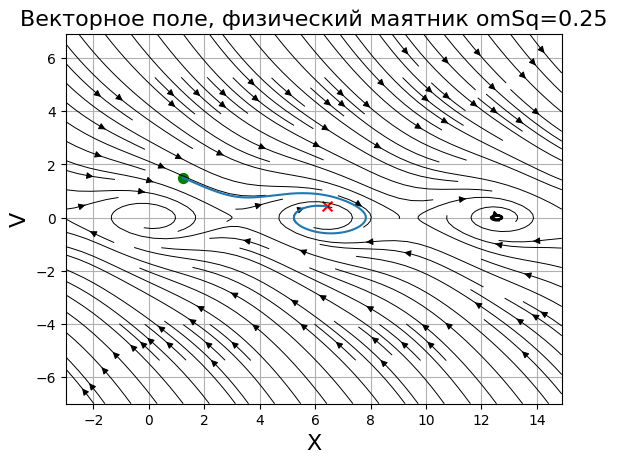

In [141]:
xx = np.arange(-3, 15, 0.1)
vv = np.arange(-7, 7, 0.1)
#makeStreamPlot(xx,vv,fPendMath, title=f"Векторное поле, математический маятник omSq={omSq}")
_,ax=makeStreamPlot(xx,vv,fPendPhysDrag, title=f"Векторное поле, физический маятник omSq={omSq}",
               xlabel="X",ylabel="V", density=1.3)
drawTraj(ax,sol.y)

## Подстройка цен

In [68]:
lam = 0.9
b = 0.3
beta = 0.5
a = 2
alpha = 0.3

#a> alpha to have equilibrium in price >0


#  X' = f (t,X),   X in Rd
def fPrice(t,sp):
    return np.concatenate([np.ones_like(sp)[...,0:1], (-lam*(b+beta)*sp + lam*(a-alpha))[...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality

# p' + lam * (b + beta) p = lam*(a - alpha)

# s' = 1
# p' = - lam*(b+beta)*p + lam*(a-alpha)
# s(0)=0, p(0)=p0

# derivation
# demand D(p) = a - b p
# supply S(p) = alpha + beta p
# p' = lam * (D(p) - S(p)) -- tuning mech

# lam,b, beta, a, alpha

(400, 250)
(400, 250, 2)


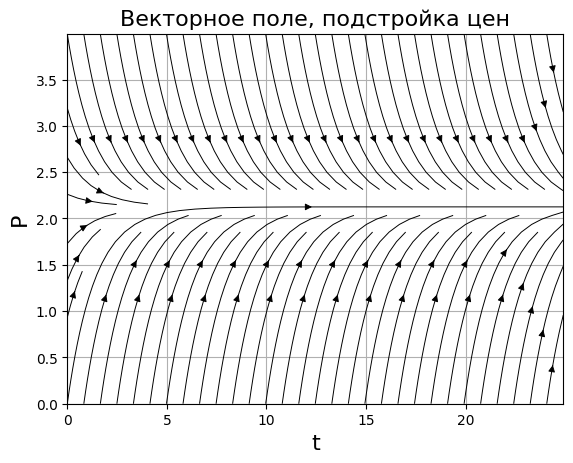

In [76]:
tt = np.arange(0, 25, 0.1)
pp = np.arange(0, 4, 0.01)
f,ax = makeStreamPlot(tt,pp,fPrice, title=f"Векторное поле, подстройка цен",
                      xlabel="t", ylabel="P", density=1.05)

plt.show()

## Рыба: уровень 1

Рыба живёт и размножается в идеальных условиях.

$$
\dot{x} = \alpha x, ~~ x(0)=x_0.
$$

In [79]:
alpha=0.15
def fFish1(t,x):
    return np.concatenate([np.ones_like(x)[...,0:1], (alpha*x)[...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality

(400, 250)
(400, 250, 2)


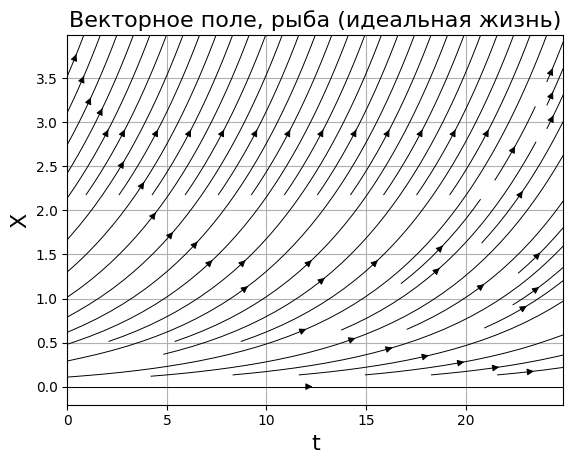

In [84]:
tt = np.arange(0, 25, 0.1)
xx = np.arange(0, 4, 0.01)
f,ax = makeStreamPlot(tt,xx,fFish1, title=f"Векторное поле, рыба (идеальная жизнь)",
                      xlabel="t", ylabel="X", density=1.05)

plt.show()

## Рыба: уровень 2

Рыба живёт и размножается, но есть конкуренция за ресурсы.

$$
\dot{x} = (\alpha -\beta x)x, ~~ x(0)=x_0.
$$

In [94]:
alpha=0.15
beta=0.05
def fFish2(t,x):
    return np.concatenate([np.ones_like(x)[...,0:1], ((alpha-beta*x)*x)[...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality

(500, 250)
(500, 250, 2)


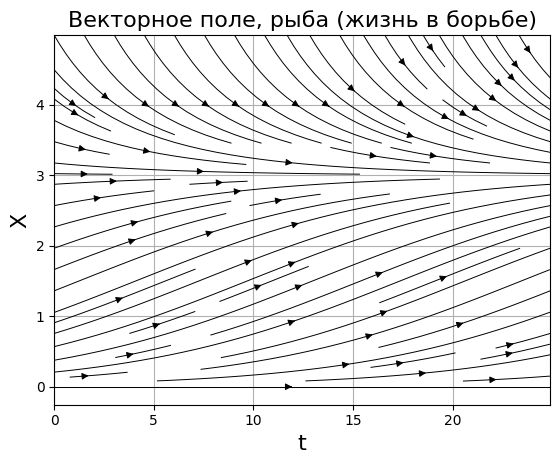

In [95]:
tt = np.arange(0, 25, 0.1)
xx = np.arange(0, 5, 0.01)
f,ax = makeStreamPlot(tt,xx,fFish2, title=f"Векторное поле, рыба (жизнь в борьбе)",
                      xlabel="t", ylabel="X", density=1.15)

plt.show()

## Рыба: уровень 3

Рыба живёт и размножается, есть конкуренция за ресурсы, а ещё люди вылавливают по $c$ условных единиц за год, $c \geq 0$.

$$
\dot{x} = (\alpha -\beta x)x - c, ~~ x(0)=x_0.
$$

In [112]:
alpha=1 #V.I. Arnold
beta=1
c = 0.2 
#<1/4 => two equilibria
#=1/4 => 1 unstable equlibrium (below = death, above = survival around equilibrium)
#>1/4 => no equilibria
def fFish3(t,x):
    return np.concatenate([np.ones_like(x)[...,0:1], ((alpha-beta*x)*x - c)[...,1:2] ], axis=-1) # 0:1 trick to conserve the dimensionality

(200, 250)
(200, 250, 2)


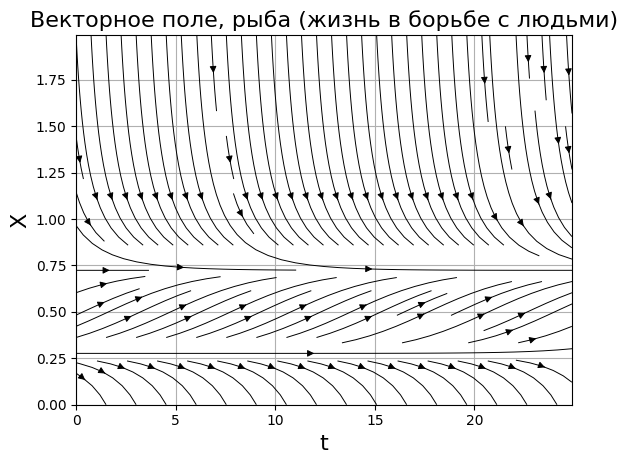

In [113]:
tt = np.arange(0, 25, 0.1)
xx = np.arange(0, 2, 0.01)
f,ax = makeStreamPlot(tt,xx,fFish3, title=f"Векторное поле, рыба (жизнь в борьбе с людьми)",
                      xlabel="t", ylabel="X", density=1.15)

plt.show()